<a href="https://colab.research.google.com/github/matthunter10/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Assignment 1


In [ ]:
#Part A

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

In [6]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [7]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [8]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [9]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


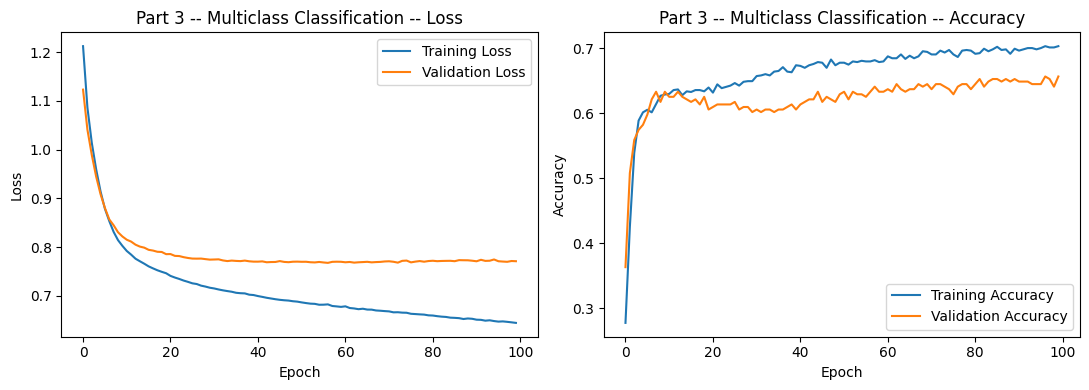

In [10]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.659


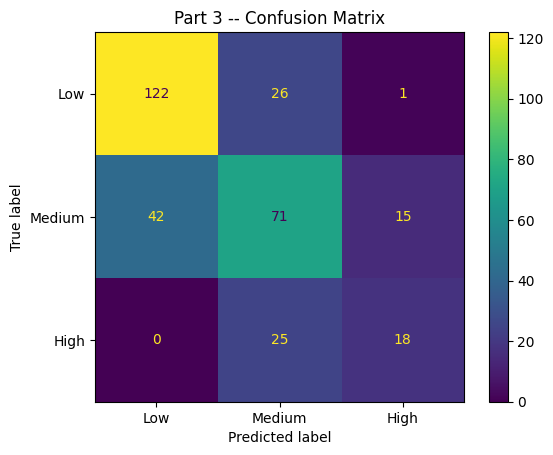

In [11]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

From our results in Lab 1 Part 3, we are able to see that we had a test accuracy of 0.659. Also from looking at the plot of the training vs validation loss curve, we can see that this is overfitting because the training loss decreases steadily. We can further make this claim because the validation loss remains some what the same after 20 epochs.

In [ ]:
#Part B

In [18]:
!pip install keras-tuner --quiet
import keras_tuner as kt

def build_model(hp):
    n_features = X3_train_scaled.shape[1]

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            units=hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu",
            input_shape=(n_features,)
        ),
        tf.keras.layers.Dense(
            units=hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [0.001, 0.01, 0.1])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
)

tuner.search(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best Hyperparameters:")
print(best_hp.values)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Hyperparameters:
{'hidden1': 112, 'hidden2': 24, 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [22]:
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
print(f"Best Validation Loss Score: {best_trial.score:.4f}")

Best Validation Loss Score: 0.7566


After running the search, the three hyperparamters we found were hidden1, hidden2, and learning_rate. This is the best configuration found and it has a validation score of 0.7566.

In [21]:
best_model = tuner.get_best_models(num_models=1)[0]
history_tuned = best_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

tuned_probs = best_model.predict(X3_test_scaled)
tuned_preds = np.argmax(tuned_probs, axis=1)
acc_tuned = accuracy_score(y3_test, tuned_preds)
print(f"Final Tuned Test Accuracy: {acc_tuned:.3f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Final Tuned Test Accuracy: 0.691


As we can see, after training our final model on our configuration that we got and evaluating it on our test set, we got an increae in our test accuracy from our original result in Lab 1. Before in lab 1 our accuracy was 0.659, but as you can see here our accuracy increased to 0.691. It improve by about 5%

In [ ]:
#Part C

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


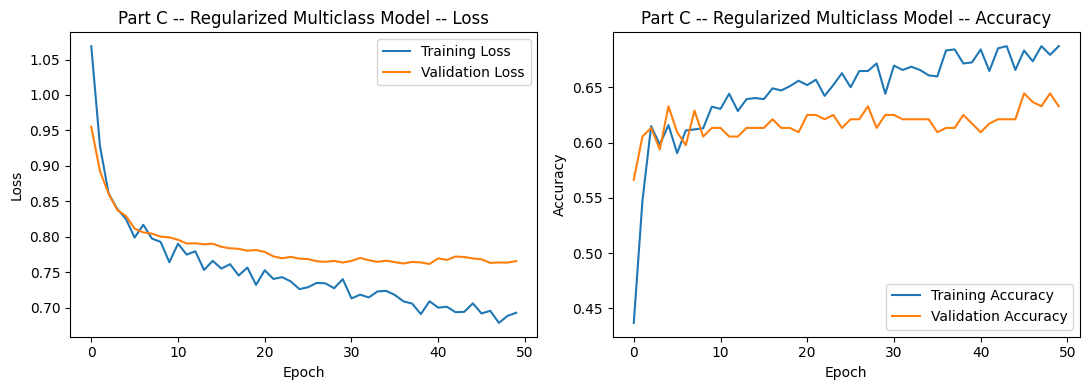

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

n_features = X3_train_scaled.shape[1]

model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(units=112, activation="relu", input_shape=(n_features,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(units=24, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_reg = model_reg.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Plot the new loss and accuracy curve to compare against Lab 1
plot_history(history_reg, "Part C -- Regularized Multiclass Model", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Part C -- Regularized Test Accuracy: 0.662


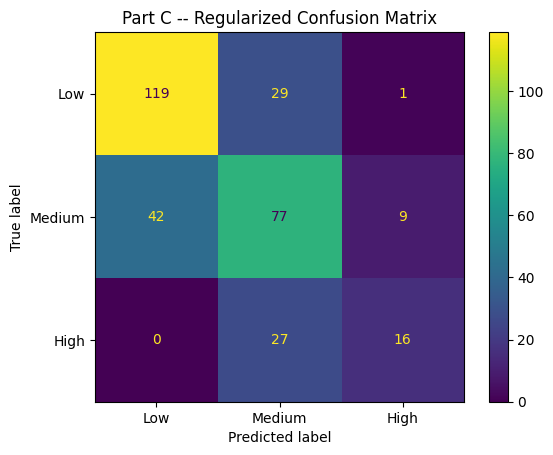

In [24]:
reg_probs = model_reg.predict(X3_test_scaled)
reg_preds = np.argmax(reg_probs, axis=1)
acc_reg = accuracy_score(y3_test, reg_preds)

print(f"Part C -- Regularized Test Accuracy: {acc_reg:.3f}")

cm_reg = confusion_matrix(y3_test, reg_preds)
ConfusionMatrixDisplay(cm_reg, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part C -- Regularized Confusion Matrix")
plt.show()

The gap between training and validation loss did shrink a bit because dropout turned off nerouns during training. The validation loss did stop rising andf stayed stable becuase we used early stopping which stopped the training at the right point.

Our final test accuracy ended up being 0.662 which was an increase from our lab 1 and you can see the confusion matrix above. The classes that our model still confuses the most are medium with low. It also confuses high with medium. This is the same classes that were being confused in Lab 1.


In [ ]:
#Part D

The test set should be used only at the end because it is meant to represent unseen data. If the test set had been used to pick the best hyperparameter configuration instead of
a validation split the final reported accuracy would be overly optimistic and would not reflect real-world performance on new, unseen data. Dropout and Early Stopping meaningfully reduced the overfitting seen in Lab 1. The new loss curve shows a much smaller and more stable gap between training and validation loss, and validation loss no longer climbs the way it did in the Part A baseline curve. With unlimited time and compute, I would next try a larger hyperparameter search, more validation strategies, and additional network architectures to see whether the model can improve further.